# Step 2: Train CRP Prediction Model

**Goal:** Train an XGBoost model to predict CRP from lifestyle variables using all 3 NHANES cycles.

By the end of this notebook you'll have a trained model saved to `ml/models/crp_model.joblib`.

In [1]:
# Cell 1: Load all 21 XPT files from 3 cycles
import pandas as pd
import numpy as np
import os

DATA_DIR = os.path.join('..', 'data', 'raw')

# Define file mappings for each cycle
cycles = {
    '2015-2016': {
        'crp': 'HSCRP_I.XPT', 'demo': 'DEMO_I.XPT', 'bmi': 'BMX_I.XPT',
        'smoking': 'SMQ_I.XPT', 'sleep': 'SLQ_I.XPT',
        'activity': 'PAQ_I.XPT', 'alcohol': 'ALQ_I.XPT'
    },
    '2017-2020': {
        'crp': 'P_HSCRP.XPT', 'demo': 'P_DEMO.XPT', 'bmi': 'P_BMX.XPT',
        'smoking': 'P_SMQ.XPT', 'sleep': 'P_SLQ.XPT',
        'activity': 'P_PAQ.XPT', 'alcohol': 'P_ALQ.XPT'
    },
    '2021-2023': {
        'crp': 'HSCRP_L.XPT', 'demo': 'DEMO_L.XPT', 'bmi': 'BMX_L.XPT',
        'smoking': 'SMQ_L.XPT', 'sleep': 'SLQ_L.XPT',
        'activity': 'PAQ_L.XPT', 'alcohol': 'ALQ_L.XPT'
    }
}

print('Loading all 21 XPT files...')
all_data = {}
for cycle_name, files in cycles.items():
    cycle_dfs = {}
    for domain, filename in files.items():
        path = os.path.join(DATA_DIR, filename)
        cycle_dfs[domain] = pd.read_sas(path, format='xport')
    all_data[cycle_name] = cycle_dfs
    total_crp = len(cycle_dfs['crp'])
    print(f'  {cycle_name}: {total_crp} participants with CRP data')

print('\nAll files loaded successfully.')

Loading all 21 XPT files...
  2015-2016: 9165 participants with CRP data
  2017-2020: 13772 participants with CRP data
  2021-2023: 8727 participants with CRP data

All files loaded successfully.


In [2]:
# Cell 2: Pick useful columns from each domain and merge per cycle

# Columns we want from each domain
COLS = {
    'crp': ['SEQN', 'LBXHSCRP'],
    'demo': ['SEQN', 'RIDAGEYR', 'RIAGENDR'],
    'bmi': ['SEQN', 'BMXBMI'],
    'smoking': ['SEQN', 'SMQ020'],
    'sleep': ['SEQN', 'SLD012', 'SLQ050'],
    'activity': ['SEQN', 'PAQ605', 'PAQ650', 'PAD680'],
    'alcohol': ['SEQN', 'ALQ101']
}

def merge_cycle(cycle_dfs):
    """Merge all domains for one cycle on SEQN."""
    merged = cycle_dfs['crp'][COLS['crp']].copy()
    for domain in ['demo', 'bmi', 'smoking', 'sleep', 'activity', 'alcohol']:
        df = cycle_dfs[domain]
        # Some cycles may not have all columns — take what exists
        available_cols = [c for c in COLS[domain] if c in df.columns]
        merged = merged.merge(df[available_cols], on='SEQN', how='left')
    return merged

cycle_merged = []
for cycle_name, cycle_dfs in all_data.items():
    m = merge_cycle(cycle_dfs)
    m['cycle'] = cycle_name
    cycle_merged.append(m)
    print(f'{cycle_name}: {len(m)} rows, {len(m.columns)} columns')

print('\nMerge per cycle complete.')

2015-2016: 9165 rows, 13 columns
2017-2020: 13772 rows, 12 columns
2021-2023: 8727 rows, 9 columns

Merge per cycle complete.


In [3]:
# Cell 3: Stack all 3 cycles into one big dataset

df = pd.concat(cycle_merged, ignore_index=True)
print(f'Combined dataset: {len(df):,} rows, {len(df.columns)} columns')
print(f'Columns: {list(df.columns)}')

Combined dataset: 31,664 rows, 13 columns
Columns: ['SEQN', 'LBXHSCRP', 'RIDAGEYR', 'RIAGENDR', 'BMXBMI', 'SMQ020', 'SLD012', 'SLQ050', 'PAQ605', 'PAQ650', 'PAD680', 'ALQ101', 'cycle']


In [4]:
# Cell 4: Clean the data

# Drop rows where CRP is missing (we need it to train)
before = len(df)
df = df.dropna(subset=['LBXHSCRP'])
print(f'Dropped {before - len(df)} rows with missing CRP')
print(f'Remaining: {len(df):,} rows')

# Drop extreme CRP outliers (likely acute infections, not lifestyle-related)
# Keep CRP < 30 mg/L (standard clinical cutoff for non-acute)
before = len(df)
df = df[df['LBXHSCRP'] < 30]
print(f'Dropped {before - len(df)} rows with CRP >= 30 (acute inflammation)')
print(f'Remaining: {len(df):,} rows')

# Recode NHANES values:
# RIAGENDR: 1=Male, 2=Female -> 0=Male, 1=Female
df['RIAGENDR'] = df['RIAGENDR'] - 1

# SMQ020: 1=Yes, 2=No, 7/9=Refused/DK -> 1=Yes, 0=No, NaN=other
df['SMQ020'] = df['SMQ020'].replace({1: 1, 2: 0, 7: np.nan, 9: np.nan})

# PAQ605/PAQ650: 1=Yes, 2=No, 7/9=Refused/DK -> 1=Yes, 0=No
for col in ['PAQ605', 'PAQ650']:
    if col in df.columns:
        df[col] = df[col].replace({1: 1, 2: 0, 7: np.nan, 9: np.nan})

# SLQ050: 1=Yes, 2=No -> 1=Yes, 0=No
df['SLQ050'] = df['SLQ050'].replace({1: 1, 2: 0, 7: np.nan, 9: np.nan})

# ALQ101: 1=Yes, 2=No -> 1=Yes, 0=No
df['ALQ101'] = df['ALQ101'].replace({1: 1, 2: 0, 7: np.nan, 9: np.nan})

# PAD680: Cap sedentary minutes at reasonable max (1440 = 24 hours)
if 'PAD680' in df.columns:
    df['PAD680'] = df['PAD680'].replace({7777: np.nan, 9999: np.nan})

print('\nCleaning complete.')
print(f'\nMissing values per column:')
print(df.drop(columns=['SEQN', 'cycle']).isnull().sum().to_string())

Dropped 4901 rows with missing CRP
Remaining: 26,763 rows
Dropped 352 rows with CRP >= 30 (acute inflammation)
Remaining: 26,411 rows

Cleaning complete.

Missing values per column:
LBXHSCRP        0
RIDAGEYR        0
RIAGENDR        0
BMXBMI        662
SMQ020       7312
SLD012       6492
SLQ050      12308
PAQ605      12192
PAQ650      12189
PAD680       6618
ALQ101      21562


In [5]:
# Cell 5: Rename columns to human-readable names

df = df.rename(columns={
    'LBXHSCRP': 'crp',
    'RIDAGEYR': 'age',
    'RIAGENDR': 'female',
    'BMXBMI': 'bmi',
    'SMQ020': 'ever_smoked',
    'SLD012': 'sleep_hours',
    'SLQ050': 'trouble_sleeping',
    'PAQ605': 'vigorous_work',
    'PAQ650': 'vigorous_recreation',
    'PAD680': 'sedentary_minutes',
    'ALQ101': 'ever_drinks'
})

# Define our feature columns and target
FEATURES = ['age', 'female', 'bmi', 'ever_smoked', 'sleep_hours',
            'trouble_sleeping', 'vigorous_work', 'vigorous_recreation',
            'sedentary_minutes', 'ever_drinks']
TARGET = 'crp'

print('Feature columns:', FEATURES)
print(f'Target: {TARGET}')
print(f'\nDataset shape: {df.shape}')
print(f'\nSample data:')
df[FEATURES + [TARGET]].head(10)

Feature columns: ['age', 'female', 'bmi', 'ever_smoked', 'sleep_hours', 'trouble_sleeping', 'vigorous_work', 'vigorous_recreation', 'sedentary_minutes', 'ever_drinks']
Target: crp

Dataset shape: (26411, 13)

Sample data:


,age,female,bmi,ever_smoked,sleep_hours,trouble_sleeping,vigorous_work,vigorous_recreation,sedentary_minutes,ever_drinks,crp
0,62.0,0.0,27.8,1.0,5.5,1.0,0.0,0.0,480.0,1.0,0.60
1,53.0,0.0,30.8,1.0,8.0,0.0,0.0,0.0,300.0,1.0,1.40
2,78.0,0.0,28.8,1.0,7.0,0.0,0.0,0.0,480.0,1.0,0.60
3,56.0,1.0,42.4,0.0,6.5,1.0,0.0,0.0,480.0,0.0,9.00
4,42.0,1.0,20.3,0.0,NaN,1.0,0.0,0.0,540.0,0.0,0.50
5,72.0,1.0,28.6,0.0,9.0,0.0,0.0,0.0,10.0,0.0,2.50
6,11.0,1.0,18.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.30
7,4.0,0.0,15.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.08
9,22.0,0.0,28.0,1.0,6.5,0.0,0.0,1.0,540.0,1.0,1.30
10,32.0,1.0,28.2,0.0,8.0,0.0,0.0,0.0,240.0,1.0,3.00


In [6]:
# Cell 6: Save cleaned dataset

out_path = os.path.join('..', 'data', 'processed', 'crp_dataset.csv')
df[FEATURES + [TARGET]].to_csv(out_path, index=False)
print(f'Saved cleaned dataset to {out_path}')
print(f'Shape: {df[FEATURES + [TARGET]].shape}')

Saved cleaned dataset to ..\data\processed\crp_dataset.csv
Shape: (26411, 11)


In [7]:
# Cell 7: Log-transform CRP and split train/test
from sklearn.model_selection import train_test_split

X = df[FEATURES].copy()
y = np.log1p(df[TARGET].values)  # log(1 + CRP) to handle zeros

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {len(X_train):,} rows')
print(f'Test set:     {len(X_test):,} rows')
print(f'\nTarget (log CRP) stats:')
print(f'  Train mean: {y_train.mean():.3f}, std: {y_train.std():.3f}')
print(f'  Test mean:  {y_test.mean():.3f}, std: {y_test.std():.3f}')

Training set: 21,128 rows
Test set:     5,283 rows

Target (log CRP) stats:
  Train mean: 1.010, std: 0.735
  Test mean:  1.020, std: 0.741


In [8]:
# Cell 8: Train XGBoost model
import xgboost as xgb

model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    enable_categorical=False,
)

print('Training XGBoost model...')
model.fit(X_train, y_train)
print('Training complete!')

Training XGBoost model...
Training complete!


MODEL EVALUATION (on unseen test data)
Mean Absolute Error:   1.89 mg/L
Median Absolute Error: 0.88 mg/L
R² Score:              0.179

Interpretation:
  On average, predictions are off by 1.9 mg/L
  For half of people, predictions are within 0.9 mg/L
  The model explains 17.9% of CRP variation

  Flat default (2.0) MAE: 2.33 mg/L
  Our model MAE:         1.89 mg/L
  Improvement:           19.0% better than flat default


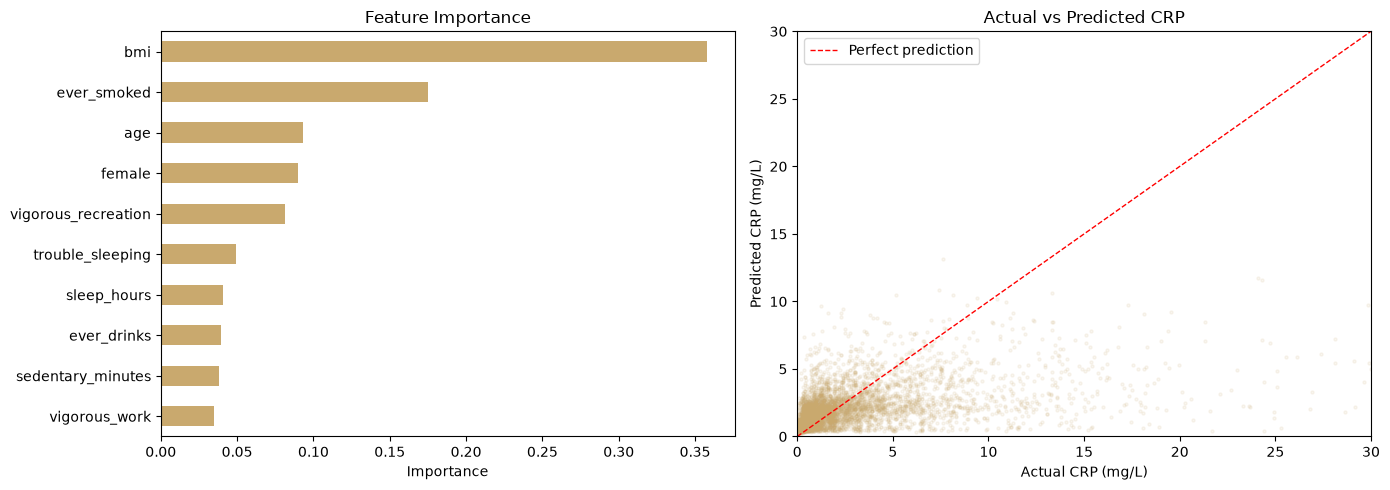

In [9]:
# Cell 9: Evaluate the model
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

# Predict on test set (in log space)
y_pred_log = model.predict(X_test)

# Convert back to original CRP scale
y_pred = np.expm1(y_pred_log)  # inverse of log1p
y_actual = np.expm1(y_test)

# Metrics
mae = mean_absolute_error(y_actual, y_pred)
r2 = r2_score(y_actual, y_pred)
median_ae = np.median(np.abs(y_actual - y_pred))

print('=' * 50)
print('MODEL EVALUATION (on unseen test data)')
print('=' * 50)
print(f'Mean Absolute Error:   {mae:.2f} mg/L')
print(f'Median Absolute Error: {median_ae:.2f} mg/L')
print(f'R² Score:              {r2:.3f}')
print()
print('Interpretation:')
print(f'  On average, predictions are off by {mae:.1f} mg/L')
print(f'  For half of people, predictions are within {median_ae:.1f} mg/L')
print(f'  The model explains {r2*100:.1f}% of CRP variation')

# Comparison with flat default
flat_default = 2.0
flat_mae = mean_absolute_error(y_actual, [flat_default] * len(y_actual))
print(f'\n  Flat default (2.0) MAE: {flat_mae:.2f} mg/L')
print(f'  Our model MAE:         {mae:.2f} mg/L')
improvement = ((flat_mae - mae) / flat_mae) * 100
print(f'  Improvement:           {improvement:.1f}% better than flat default')

# Feature importance plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature importance
importance = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
importance.plot(kind='barh', ax=axes[0], color='#C9A96E')
axes[0].set_title('Feature Importance')
axes[0].set_xlabel('Importance')

# Actual vs Predicted scatter
axes[1].scatter(y_actual, y_pred, alpha=0.1, s=5, color='#C9A96E')
max_val = min(30, max(y_actual.max(), y_pred.max()))
axes[1].plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='Perfect prediction')
axes[1].set_xlabel('Actual CRP (mg/L)')
axes[1].set_ylabel('Predicted CRP (mg/L)')
axes[1].set_title('Actual vs Predicted CRP')
axes[1].set_xlim(0, 30)
axes[1].set_ylim(0, 30)
axes[1].legend()

plt.tight_layout()
plt.show()

In [10]:
# Cell 10: Save the trained model
import joblib

model_path = os.path.join('..', 'models', 'crp_model.joblib')
joblib.dump({
    'model': model,
    'features': FEATURES,
    'mae': mae,
    'r2': r2,
    'median_ae': median_ae,
    'training_rows': len(X_train),
    'test_rows': len(X_test),
}, model_path)

file_size = os.path.getsize(model_path) / 1024
print(f'Model saved to: {model_path}')
print(f'File size: {file_size:.0f} KB')
print(f'\nTo load and use:')
print(f'  import joblib')
print(f'  data = joblib.load("{model_path}")')
print(f'  model = data["model"]')
print(f'  prediction = np.expm1(model.predict(input_df))  # CRP in mg/L')

Model saved to: ..\models\crp_model.joblib
File size: 783 KB

To load and use:
  import joblib
  data = joblib.load("..\models\crp_model.joblib")
  model = data["model"]
  prediction = np.expm1(model.predict(input_df))  # CRP in mg/L
